In [1]:
import pandas as pd
import os
import glob
import geopandas as gpd

In [2]:
sdrf = pd.read_csv(r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items_clean.csv")
sdrf

,source,page,sl_no,district,department,work_text,work_type,disaster_phase,classify_confidence,amount_inr,...,amount_inr_clean,amount_lakh_clean,amount_unit_basis,amount_outlier,allocation_inr,district_canon,district_level,disaster_type,department_orig,department_source
0,10th_SEC_Meeting,4,NaN,NaN,Home Department,Widening of Roads in Guwahati City,Roads & Bridges,Unclassified,medium,540000000.0,...,540000000.0,5400.0000,kept,False,540000000.0,NaN,unmapped,Unspecified / Multi-hazard,Home Department,extracted
1,10th_SEC_Meeting,9,1,Majuli,Home Department,Construction of FCI Godowns,Other / Unclassified,Unclassified,low,NaN,...,NaN,NaN,kept,False,NaN,MAJULI,district,Unspecified / Multi-hazard,Home Department,extracted
2,10th_SEC_Meeting,9,2,Majuli,Home Department,Procurement of two wooden boats each for Majul...,Equipment / Procurement,Long-term Preparedness,high,3856508.0,...,3856508.0,38.5651,kept,False,3856508.0,MAJULI,district,Unspecified / Multi-hazard,Home Department,extracted
3,10th_SEC_Meeting,9,3,Majuli,Home Department,Revive the dairy cooperatives as a livelihood ...,Other / Unclassified,Unclassified,low,NaN,...,NaN,NaN,kept,False,NaN,MAJULI,district,Flood,Home Department,extracted
4,10th_SEC_Meeting,18,1,NaN,Home Department,"Hiring of Innova for use of CEO, ASDMA whose s...",Health / Veterinary response,Unclassified,medium,658000.0,...,658000.0,6.5800,kept,False,658000.0,NaN,unmapped,Unspecified / Multi-hazard,Home Department,extracted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8339,55th_sec_meeting_0,92,13,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,118000.0,...,118000.0,1.1800,kept,False,118000.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8340,55th_sec_meeting_0,92,14,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,1036040.0,...,1036040.0,10.3604,kept,False,1036040.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8341,55th_sec_meeting_0,92,15,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,2056740.0,...,2056740.0,20.5674,kept,False,2056740.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8342,55th_sec_meeting_0,93,1,Hailakandi,Soil Conservation,"Immediate restoration of damaged 11 kV line, L...",Restoration of damaged assets,Repair and Restoration,high,1162300.0,...,1162300.0,11.6230,kept,False,1162300.0,HAILAKANDI,district,Flood,Soil Conservation,extracted


In [3]:
district = gpd.read_file(r'/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Maps/Geojson/assam_district_2024-11.geojson')
canon_district = district['dtname'].to_list()
canon_district

['TINSUKIA',
 'DHUBRI',
 'BARPETA',
 'MAJULI',
 'HAILAKANDI',
 'TAMULPUR',
 'SIVASAGAR',
 'BAKSA',
 'KAMRUP',
 'DHEMAJI',
 'SOUTH SALMARA MANCACHAR',
 'CHIRANG',
 'SONITPUR',
 'UDALGURI',
 'WEST KARBI ANGLONG',
 'JORHAT',
 'GOALPARA',
 'CHARAIDEO',
 'BONGAIGAON',
 'GOLAGHAT',
 'KARIMGANJ',
 'NAGAON',
 'BISWANATH',
 'KARBI ANGLONG',
 'KOKRAJHAR',
 'DIBRUGARH',
 'LAKHIMPUR',
 'HOJAI',
 'MORIGAON',
 'BAJALI',
 'CACHAR',
 'KAMRUP METRO',
 'NALBARI',
 'DIMA HASAO',
 'DARRANG']

In [4]:
sdrf_floods = sdrf.loc[sdrf['disaster_type'] == 'Flood']
sdrf_floods_preparedness = sdrf_floods.loc[sdrf_floods['disaster_phase'] == 'Long-term Preparedness']
fiscal_year_preparedness = sdrf_floods_preparedness.groupby('fiscal_year', as_index=False)['amount_inr_clean'].sum()
fiscal_year_preparedness.sort_values('amount_inr_clean', ascending=False)

,fiscal_year,amount_inr_clean
3,2024-25,159178500.0
2,2022-23,31660000.0
4,2025-26,13490000.0
1,2021-22,8400000.0
0,2019-20,3100000.0


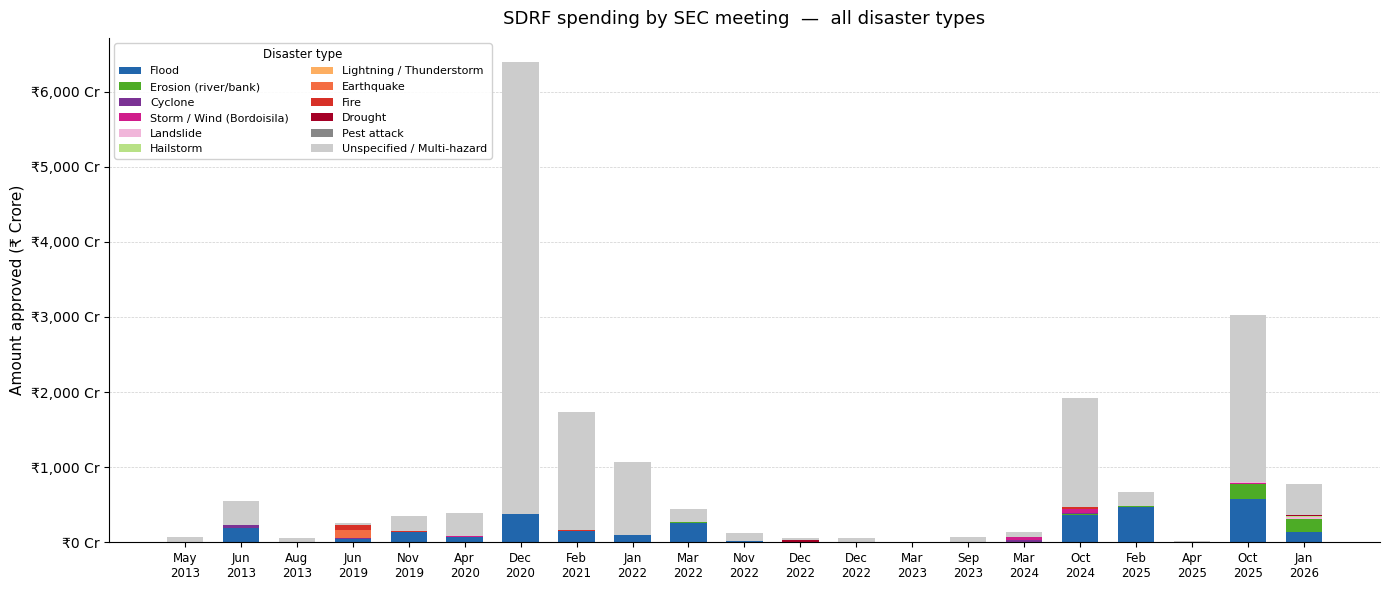

disaster_type   TOTAL  Flood  Erosion (river/bank)  Cyclone  Storm / Wind (Bordoisila)  Landslide  Hailstorm  Lightning / Thunderstorm  Earthquake  Fire  Drought  Pest attack  Unspecified / Multi-hazard
meeting_date                                                                                                                                                                                              
2013-05-03       73.6    0.0                   0.0      0.0                        0.0        0.0        0.0                       0.0         0.3   0.0      0.0          0.0                        73.3
2013-06-07      548.5  183.5                   0.2     40.0                        0.0        0.0        0.6                       0.0         0.0   0.0     10.0          0.0                       314.2
2013-08-29       60.6    5.8                   0.0      0.0                        0.0        0.0        0.0                       0.0         0.0   0.0      0.0          0.0              

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import numpy as np

# --- aggregate by meeting date × disaster type ---
df_plot = sdrf.dropna(subset=["meeting_date", "amount_inr_clean"]).copy()
df_plot["meeting_date"] = pd.to_datetime(df_plot["meeting_date"])

DISASTER_ORDER = [
    "Flood",
    "Erosion (river/bank)",
    "Cyclone",
    "Storm / Wind (Bordoisila)",
    "Landslide",
    "Hailstorm",
    "Lightning / Thunderstorm",
    "Earthquake",
    "Fire",
    "Drought",
    "Pest attack",
    "Unspecified / Multi-hazard",
]
COLORS = [
    "#2166ac", "#4dac26", "#7b3294", "#d01c8b",
    "#f1b6da", "#b8e186", "#fdae61", "#f46d43",
    "#d73027", "#a50026", "#878787", "#cccccc",
]
color_map = dict(zip(DISASTER_ORDER, COLORS))

pivot = (
    df_plot
    .groupby(["meeting_date", "disaster_type"])["amount_inr_clean"]
    .sum()
    .unstack(fill_value=0)
)
# reorder columns to match DISASTER_ORDER, keeping any extras at the end
ordered_cols = [c for c in DISASTER_ORDER if c in pivot.columns]
pivot = pivot[ordered_cols] / 1e7  # convert to crore

fig, ax = plt.subplots(figsize=(14, 6))

dates = pivot.index
x = np.arange(len(dates))
bar_width = 0.65

bottoms = np.zeros(len(dates))
for col in ordered_cols:
    vals = pivot[col].values
    ax.bar(x, vals, bar_width, bottom=bottoms,
           color=color_map[col], label=col, zorder=2)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(
    [d.strftime("%b\n%Y") for d in dates],
    fontsize=8.5
)
ax.set_ylabel("Amount approved (₹ Crore)", fontsize=11)
ax.set_title("SDRF spending by SEC meeting  —  all disaster types", fontsize=13, pad=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"₹{v:,.0f} Cr"))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    loc="upper left", fontsize=8, framealpha=0.9,
    ncol=2, title="Disaster type", title_fontsize=8.5,
)

plt.tight_layout()
plt.show()

# --- summary table ---
pivot["TOTAL"] = pivot.sum(axis=1)
print(pivot[["TOTAL"] + ordered_cols].to_string(float_format=lambda v: f"{v:,.1f}"))

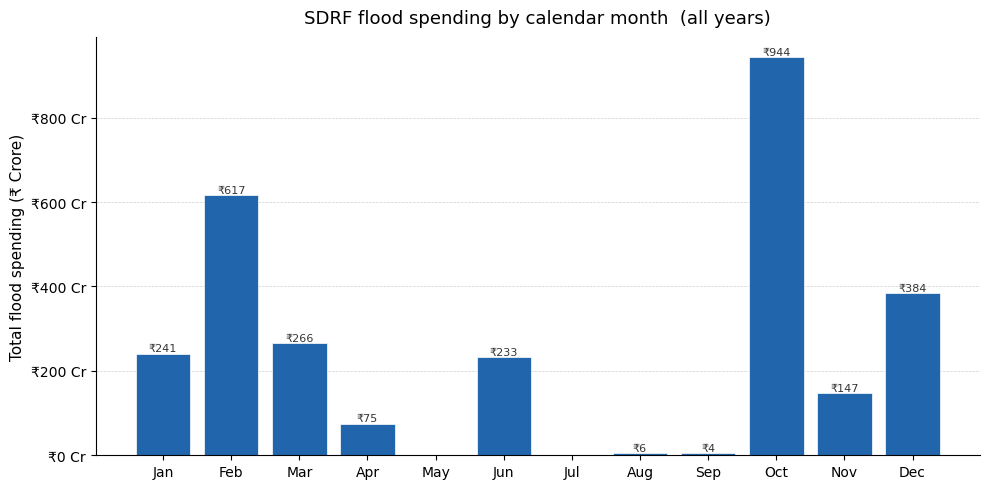

Meetings contributing to each month:
month
1                 [2022-01-11, 2026-01-28]
2                 [2021-02-13, 2025-02-03]
3     [2022-03-23, 2023-03-29, 2024-03-01]
4                 [2020-04-29, 2025-04-09]
6                 [2013-06-07, 2019-06-10]
8                             [2013-08-29]
9                             [2023-09-07]
10                [2024-10-01, 2025-10-09]
11                [2019-11-27, 2022-11-04]
12    [2020-12-01, 2022-12-06, 2022-12-10]
Name: meeting_date, dtype: object


In [6]:
floods = sdrf.loc[
    (sdrf["disaster_type"] == "Flood") & sdrf["amount_inr_clean"].notna()
].copy()
floods["meeting_date"] = pd.to_datetime(floods["meeting_date"])
floods["month"] = floods["meeting_date"].dt.month

monthly = floods.groupby("month")["amount_inr_clean"].sum() / 1e7

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    monthly.index, monthly.values,
    color="#2166ac", edgecolor="white", linewidth=0.5, zorder=2,
)

for bar, val in zip(bars, monthly.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"₹{val:,.0f}", ha="center", va="bottom", fontsize=8, color="#333333",
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel("Total flood spending (₹ Crore)", fontsize=11)
ax.set_title("SDRF flood spending by calendar month  (all years)", fontsize=13, pad=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"₹{v:,.0f} Cr"))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Meetings contributing to each month:")
print(floods.groupby("month")["meeting_date"].apply(lambda d: sorted(d.dt.strftime("%Y-%m-%d").unique())))

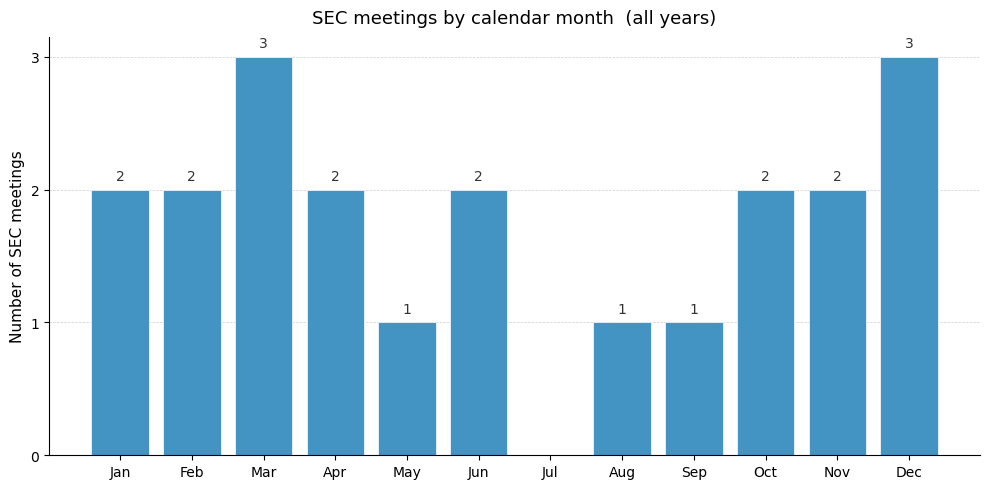

In [7]:
meeting_dates = pd.to_datetime(sdrf["meeting_date"].dropna().unique())
meetings_by_month = pd.Series(meeting_dates).dt.month.value_counts().reindex(range(1, 13), fill_value=0)

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    meetings_by_month.index, meetings_by_month.values,
    color="#4393c3", edgecolor="white", linewidth=0.5, zorder=2,
)

for bar, val in zip(bars, meetings_by_month.values):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontsize=10, color="#333333",
        )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel("Number of SEC meetings", fontsize=11)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_title("SEC meetings by calendar month  (all years)", fontsize=13, pad=10)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

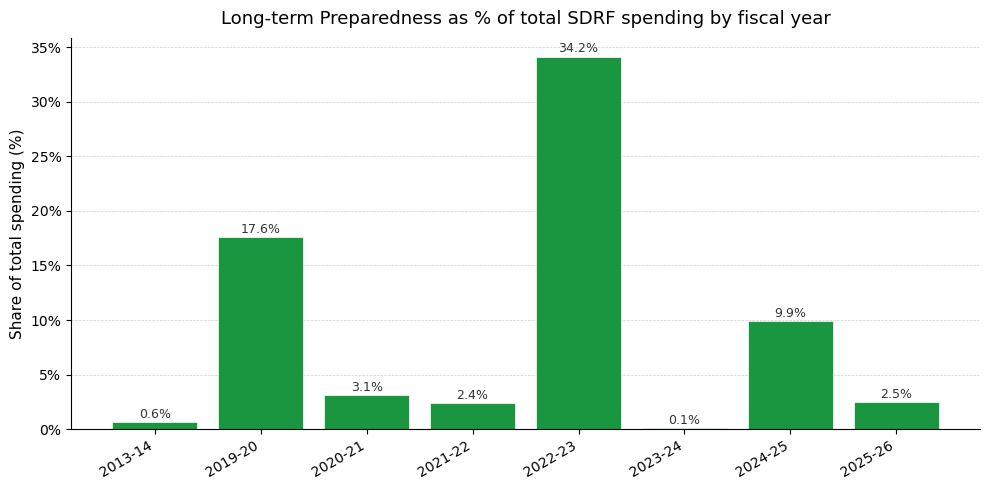

             Total (₹ Cr)  Preparedness (₹ Cr)  Prep %
fiscal_year                                           
2013-14            682.65                 4.24    0.62
2019-20            609.53               107.41   17.62
2020-21           8526.38               266.18    3.12
2021-22           1518.59                36.29    2.39
2022-23            229.40                78.35   34.15
2023-24            206.18                 0.24    0.12
2024-25           2583.02               255.72    9.90
2025-26           3817.96                93.90    2.46


In [8]:
by_year = sdrf.dropna(subset=["amount_inr_clean"]).groupby("fiscal_year")["amount_inr_clean"].sum()
prep_by_year = (
    sdrf.loc[(sdrf["disaster_phase"] == "Long-term Preparedness") & sdrf["amount_inr_clean"].notna() ]
    .groupby("fiscal_year")["amount_inr_clean"].sum()
)

pct = (prep_by_year / by_year * 100).dropna().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(len(pct)), pct.values, color="#1a9641", edgecolor="white", linewidth=0.5, zorder=2)

for bar, val in zip(bars, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
        f"{val:.1f}%", ha="center", va="bottom", fontsize=9, color="#333333",
    )

ax.set_xticks(range(len(pct)))
ax.set_xticklabels(pct.index, rotation=30, ha="right")
ax.set_ylabel("Share of total spending (%)", fontsize=11)
ax.set_title("Long-term Preparedness as % of total SDRF spending by fiscal year", fontsize=13, pad=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Total (₹ Cr)":         (by_year / 1e7).round(2),
    "Preparedness (₹ Cr)":  (prep_by_year / 1e7).fillna(0).round(2),
    "Prep %":                pct.round(2),
})
print(summary.to_string())

In [9]:
sdrf_districts = sdrf.loc[sdrf['district_canon'].notnull()]
sdrf_districts

,source,page,sl_no,district,department,work_text,work_type,disaster_phase,classify_confidence,amount_inr,...,amount_inr_clean,amount_lakh_clean,amount_unit_basis,amount_outlier,allocation_inr,district_canon,district_level,disaster_type,department_orig,department_source
1,10th_SEC_Meeting,9,1,Majuli,Home Department,Construction of FCI Godowns,Other / Unclassified,Unclassified,low,NaN,...,NaN,NaN,kept,False,NaN,MAJULI,district,Unspecified / Multi-hazard,Home Department,extracted
2,10th_SEC_Meeting,9,2,Majuli,Home Department,Procurement of two wooden boats each for Majul...,Equipment / Procurement,Long-term Preparedness,high,3856508.0,...,3856508.0,38.5651,kept,False,3856508.0,MAJULI,district,Unspecified / Multi-hazard,Home Department,extracted
3,10th_SEC_Meeting,9,3,Majuli,Home Department,Revive the dairy cooperatives as a livelihood ...,Other / Unclassified,Unclassified,low,NaN,...,NaN,NaN,kept,False,NaN,MAJULI,district,Flood,Home Department,extracted
38,11th_SEC-SDRF_Meeting_0,2,1,Baska (Baska W.R. Divn.),Water Resources,I/M to Somnahari at 12th Km L/B of river Puthi...,Roads & Bridges,Unclassified,medium,23518000.0,...,23518000.0,235.1800,kept,False,23518000.0,Baska (Baska W.R. Divn.),unmapped,Unspecified / Multi-hazard,Water Resources,extracted
39,11th_SEC-SDRF_Meeting_0,2,2,Udalguri,Water Resources,Changes of river course at Kadamtola from the ...,Capacity building / Training,Unclassified,medium,6768000.0,...,6768000.0,67.6800,kept,False,6768000.0,UDALGURI,district,Unspecified / Multi-hazard,Water Resources,extracted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8339,55th_sec_meeting_0,92,13,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,118000.0,...,118000.0,1.1800,kept,False,118000.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8340,55th_sec_meeting_0,92,14,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,1036040.0,...,1036040.0,10.3604,kept,False,1036040.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8341,55th_sec_meeting_0,92,15,Bongaigaon,Soil Conservation,Immediate restoration of damaged of 11 kv line...,Restoration of damaged assets,Repair and Restoration,high,2056740.0,...,2056740.0,20.5674,kept,False,2056740.0,BONGAIGAON,district,Storm / Wind (Bordoisila),Soil Conservation,extracted
8342,55th_sec_meeting_0,93,1,Hailakandi,Soil Conservation,"Immediate restoration of damaged 11 kV line, L...",Restoration of damaged assets,Repair and Restoration,high,1162300.0,...,1162300.0,11.6230,kept,False,1162300.0,HAILAKANDI,district,Flood,Soil Conservation,extracted


In [10]:
sdrf_districts_floods = sdrf_districts.loc[sdrf_districts['disaster_type'] == 'Flood']
sdrf_districts_floods_preparedness = sdrf_districts_floods.loc[sdrf_districts_floods['disaster_phase'] == 'Long-term Preparedness']
fiscal_year_preparedness = sdrf_districts_floods_preparedness.groupby('fiscal_year', as_index=False)['amount_inr_clean'].sum()
fiscal_year_preparedness

,fiscal_year,amount_inr_clean
0,2019-20,3100000.0


In [11]:
ids_dist_2022_23 = ["Bajali", "Barpeta", "Lakhimpur", "Bongaigon", "Nagaon"]
ids_dist_2025_26 = ["Cachar", "Lakhimpur", "Karimganj", "Barpeta", "Nagaon", "Kamrup Metro", "Majuli", "Udalguri", "Darrang", "Dibrugarh"]
ids_dist_rec_2025_26 = ["Cachar", "Lakhimpur", "Barpeta", "Nagaon", "Majuli", "Darrang", "Dibrugarh"]

common_dist = ["Lakhimpur", "Barpeta", "Nagaon"]


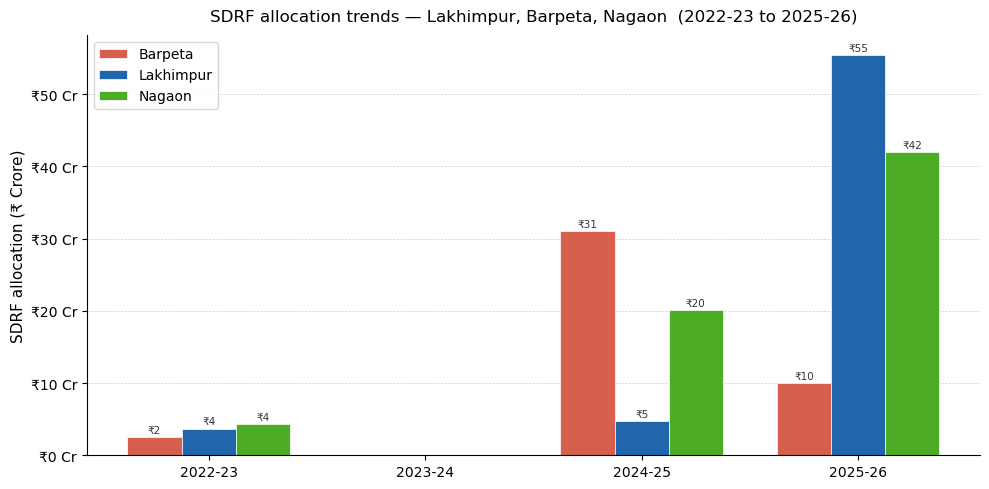

               Barpeta  Lakhimpur     Nagaon
fiscal_year                                 
2022-23       ₹2.48 Cr   ₹3.70 Cr   ₹4.33 Cr
2023-24       ₹0.00 Cr   ₹0.00 Cr   ₹0.00 Cr
2024-25      ₹31.04 Cr   ₹4.76 Cr  ₹20.14 Cr
2025-26      ₹10.03 Cr  ₹55.44 Cr  ₹41.93 Cr


/var/folders/mn/tyjcr2q91wz11fzw0ttcj3780000gn/T/ipykernel_92680/644261560.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot.applymap(lambda v: f"₹{v:.2f} Cr").to_string())


In [12]:
YEARS = ["2022-23", "2023-24", "2024-25", "2025-26"]
DIST_CANON = {d: d.upper() for d in common_dist}   # Lakhimpur → LAKHIMPUR etc.
DIST_COLORS = {"Lakhimpur": "#2166ac", "Barpeta": "#d6604d", "Nagaon": "#4dac26"}

sub = sdrf.loc[
    sdrf["district_canon"].isin(DIST_CANON.values()) &
    sdrf["fiscal_year"].isin(YEARS) &
    sdrf["amount_inr_clean"].notna()
]

pivot = (
    sub.groupby(["fiscal_year", "district_canon"])["amount_inr_clean"]
    .sum()
    .unstack(fill_value=0)
    .reindex(YEARS, fill_value=0)
    / 1e7
)
# rename canonical → display names
pivot.columns = {v: k for k, v in DIST_CANON.items()}[pivot.columns] \
    if False else [next(k for k, v in DIST_CANON.items() if v == c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(YEARS))
n = len(pivot.columns)
width = 0.25
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

for i, dist in enumerate(pivot.columns):
    vals = pivot[dist].values
    bars = ax.bar(x + offsets[i], vals, width, label=dist,
                  color=DIST_COLORS[dist], edgecolor="white", linewidth=0.5, zorder=2)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"₹{val:.0f}", ha="center", va="bottom", fontsize=7.5, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(YEARS)
ax.set_ylabel("SDRF allocation (₹ Crore)", fontsize=11)
ax.set_title("SDRF allocation trends — Lakhimpur, Barpeta, Nagaon  (2022-23 to 2025-26)",
             fontsize=12, pad=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"₹{v:.0f} Cr"))
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(pivot.applymap(lambda v: f"₹{v:.2f} Cr").to_string())

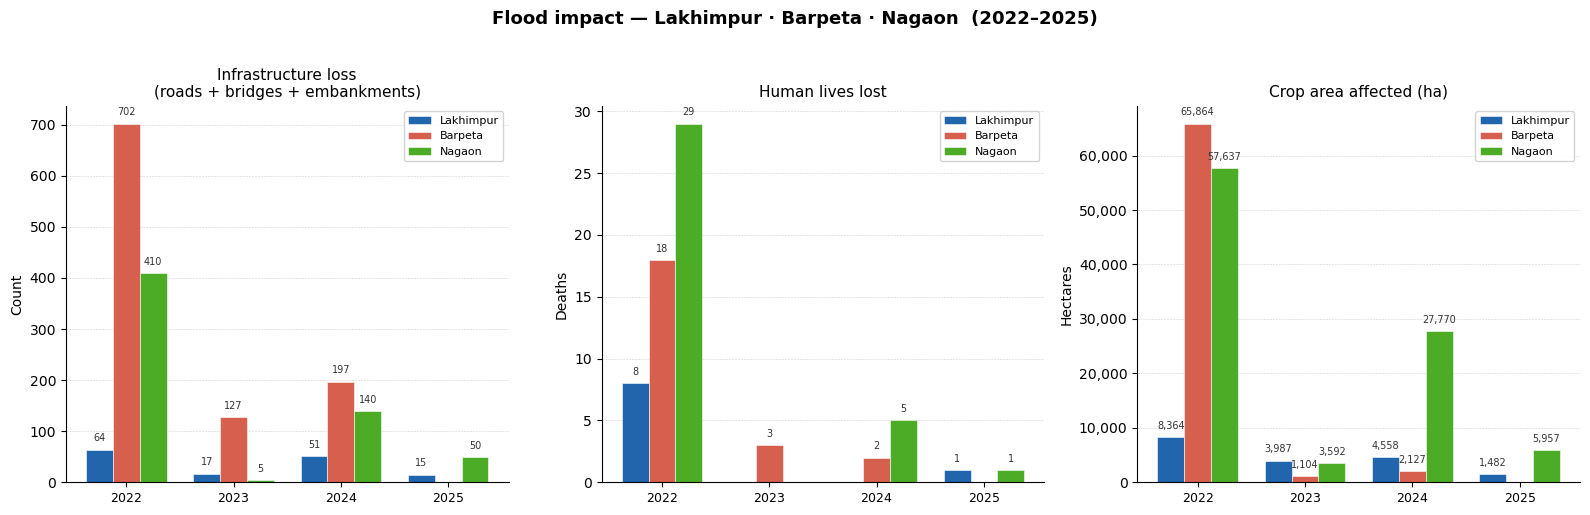

In [13]:
import matplotlib.gridspec as gridspec

DISTS      = ["Lakhimpur", "Barpeta", "Nagaon"]
DIST_CANON = {d: d.upper() for d in DISTS}
COLORS     = {"Lakhimpur": "#2166ac", "Barpeta": "#d6604d", "Nagaon": "#4dac26"}

CAL_YEARS = [2022, 2023, 2024, 2025]

# ── MASTER_VARIABLES: annual impact ──────────────────────────────────────────
mv = pd.read_csv(
    r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/MASTER_VARIABLES.csv"
)
mv_tgt = mv[mv["district"].isin(DIST_CANON.values())].copy()
mv_tgt["year"] = mv_tgt["timeperiod"].str[:4].astype(int)
mv_tgt["infra_loss"] = mv_tgt["Roads"] + mv_tgt["Bridge"] + mv_tgt["Embankment breached"]

impact = (
    mv_tgt.groupby(["year", "district"])[["infra_loss", "Human_Live_Lost", "Crop_Area"]]
    .sum()
    .unstack("district")
    .reindex(CAL_YEARS, fill_value=0)
)
impact.columns = pd.MultiIndex.from_tuples(
    [(m, {v: k for k, v in DIST_CANON.items()}[d]) for m, d in impact.columns],
    names=["metric", "district"]
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Flood impact — Lakhimpur · Barpeta · Nagaon  (2022–2025)",
             fontsize=13, fontweight="bold", y=1.02)

x = np.arange(len(CAL_YEARS))
w = 0.25
offsets = np.linspace(-(len(DISTS)-1)/2, (len(DISTS)-1)/2, len(DISTS)) * w

def grouped_bars(ax, metric, ylabel, title, y_fmt=None):
    data = impact[metric]
    ymax = data.values.max() * 1.15 or 1
    for i, dist in enumerate(DISTS):
        vals = data[dist].values
        bars = ax.bar(x + offsets[i], vals, w, label=dist,
                      color=COLORS[dist], edgecolor="white", linewidth=0.4, zorder=2)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax * 0.015,
                        f"{val:,.0f}", ha="center", va="bottom", fontsize=7, color="#333")
    ax.set_xticks(x)
    ax.set_xticklabels(CAL_YEARS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.6, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.85)
    if y_fmt:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(y_fmt))

grouped_bars(axes[0], "infra_loss",      "Count",    "Infrastructure loss\n(roads + bridges + embankments)")
grouped_bars(axes[1], "Human_Live_Lost", "Deaths",   "Human lives lost")
grouped_bars(axes[2], "Crop_Area",       "Hectares", "Crop area affected (ha)",
             y_fmt=lambda v, _: f"{v:,.0f}")

plt.tight_layout()
plt.show()

### Infrastructure Investment Analysis

In [14]:
infra_work_type = ['Embankment / Flood protection', 'Roads & Bridges','Buildings / Shelter']

In [15]:
ids_dist_2025_26_canon = [d.upper() for d in ids_dist_2025_26]
ids_dist_rec_2025_26_canon = [d.upper() for d in ids_dist_rec_2025_26]
infra_df = sdrf.loc[
    sdrf['district_canon'].isin(ids_dist_2025_26_canon) &
    (sdrf['fiscal_year'] == '2025-26') &
    sdrf['work_type'].isin(infra_work_type)
]

infra_df

,source,page,sl_no,district,department,work_text,work_type,disaster_phase,classify_confidence,amount_inr,...,amount_inr_clean,amount_lakh_clean,amount_unit_basis,amount_outlier,allocation_inr,district_canon,district_level,disaster_type,department_orig,department_source
7536,53rd_sec_meeting_2,20,97,Darang,PWD,Restoration of Dhula Kharupetia Road under SD...,Roads & Bridges,Repair and Restoration,high,318000.0,...,318000.0,3.18,kept,False,318000.0,DARRANG,district,Unspecified / Multi-hazard,PWD,extracted
7537,53rd_sec_meeting_2,20,98,Darang,PWD,Temporary Restoration of Dumnichowki Khataa Ro...,Roads & Bridges,Repair and Restoration,high,240000.0,...,240000.0,2.40,kept,False,240000.0,DARRANG,district,Unspecified / Multi-hazard,PWD,extracted
7538,53rd_sec_meeting_2,21,99,Darang,PWD,Temporary restoration of Soalpam to Dumnichowk...,Roads & Bridges,Repair and Restoration,high,175000.0,...,175000.0,1.75,kept,False,175000.0,DARRANG,district,Unspecified / Multi-hazard,PWD,extracted
7539,53rd_sec_meeting_2,21,100,Darang,PWD,Temporary restoration of Soalpam Badiasissa Ro...,Roads & Bridges,Repair and Restoration,high,120000.0,...,120000.0,1.20,kept,False,120000.0,DARRANG,district,Unspecified / Multi-hazard,PWD,extracted
7540,53rd_sec_meeting_2,21,101,Darang,PWD,Temporary restoration of Janasewa Kathamara Ro...,Roads & Bridges,Repair and Restoration,high,179000.0,...,179000.0,1.79,kept,False,179000.0,DARRANG,district,Unspecified / Multi-hazard,PWD,extracted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8181,55th_sec_meeting_0,64,198,Nagaon,Soil Conservation,Temporary restoration of flood damaged on Khaw...,Roads & Bridges,Repair and Restoration,high,25000.0,...,25000.0,0.25,kept,False,25000.0,NAGAON,district,Flood,Soil Conservation,extracted
8182,55th_sec_meeting_0,65,199,Nagaon,Soil Conservation,Removal of accumulated of Water hyacinth and D...,Roads & Bridges,Unclassified,medium,671000.0,...,671000.0,6.71,kept,False,671000.0,NAGAON,district,Flood,Soil Conservation,extracted
8324,55th_sec_meeting_0,88,342,Udalguri,Soil Conservation,Temporary restoration of Rupahihat Charpara Ro...,Roads & Bridges,Repair and Restoration,high,500000.0,...,500000.0,5.00,kept,False,500000.0,UDALGURI,district,Unspecified / Multi-hazard,Soil Conservation,extracted
8325,55th_sec_meeting_0,88,343,Udalguri,Soil Conservation,Temporary restoration of Mangaldai Bhutidang R...,Roads & Bridges,Repair and Restoration,high,500000.0,...,500000.0,5.00,kept,False,500000.0,UDALGURI,district,Unspecified / Multi-hazard,Soil Conservation,extracted


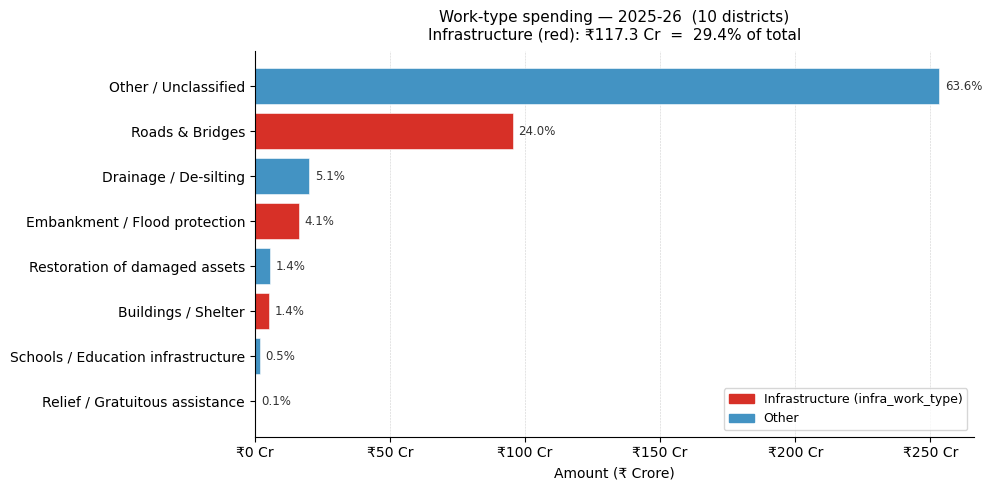

                                    ₹ Crore  % of total
work_type                                              
Other / Unclassified                 253.41        63.6
Roads & Bridges                       95.52        24.0
Drainage / De-silting                 20.15         5.1
Embankment / Flood protection         16.33         4.1
Restoration of damaged assets          5.53         1.4
Buildings / Shelter                    5.40         1.4
Schools / Education infrastructure     1.84         0.5
Relief / Gratuitous assistance         0.23         0.1
──────────────────────────────          NaN         NaN
Total                                398.42       100.0
  Infrastructure subtotal            117.25        29.4


/var/folders/mn/tyjcr2q91wz11fzw0ttcj3780000gn/T/ipykernel_92680/3696470178.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary.loc['─' * 30] = [None, None]


In [16]:
df_2526 = sdrf.loc[
    sdrf['district_canon'].isin(ids_dist_rec_2025_26_canon) &
    (sdrf['fiscal_year'] == '2025-26') &
    sdrf['amount_inr_clean'].notna()
].copy()

by_work = df_2526.groupby('work_type')['amount_inr_clean'].sum().sort_values(ascending=False)
total      = by_work.sum()
infra_total = by_work[by_work.index.isin(infra_work_type)].sum()
infra_pct   = infra_total / total * 100
pct         = (by_work / total * 100).round(1)

# ── Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#d73027' if wt in infra_work_type else '#4393c3' for wt in by_work.index]
bars = ax.barh(
    by_work.index[::-1], by_work.values[::-1] / 1e7,
    color=bar_colors[::-1], edgecolor='white', linewidth=0.4, zorder=2
)

for bar, p in zip(bars, pct.values[::-1]):
    ax.text(
        bar.get_width() + total / 1e7 * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{p:.1f}%', va='center', fontsize=8.5, color='#333'
    )

ax.set_xlabel('Amount (₹ Crore)', fontsize=10)
ax.set_title(
    f'Work-type spending — 2025-26  ({len(ids_dist_2025_26_canon)} districts)\n'
    f'Infrastructure (red): ₹{infra_total/1e7:.1f} Cr  =  {infra_pct:.1f}% of total',
    fontsize=11, pad=8
)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'₹{v:.0f} Cr'))
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.6, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d73027', label='Infrastructure (infra_work_type)'),
    Patch(color='#4393c3', label='Other'),
], fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({'₹ Crore': (by_work / 1e7).round(2), '% of total': pct})
summary.loc['─' * 30] = [None, None]
summary.loc['Total'] = [round(total / 1e7, 2), 100.0]
summary.loc['  Infrastructure subtotal'] = [round(infra_total / 1e7, 2), round(infra_pct, 1)]
print(summary.to_string())

                         work_type  n_items  amount_cr  share_pct
           Equipment / Procurement       84      238.0       28.2
      Capacity building / Training       63      204.8       24.3
    Relief / Gratuitous assistance        3      188.2       22.3
               Buildings / Shelter       23      152.7       18.1
                   Roads & Bridges        7       50.7        6.0
              Other / Unclassified       15        5.6        0.7
Schools / Education infrastructure        9        2.0        0.2
     Embankment / Flood protection        1        0.3        0.0


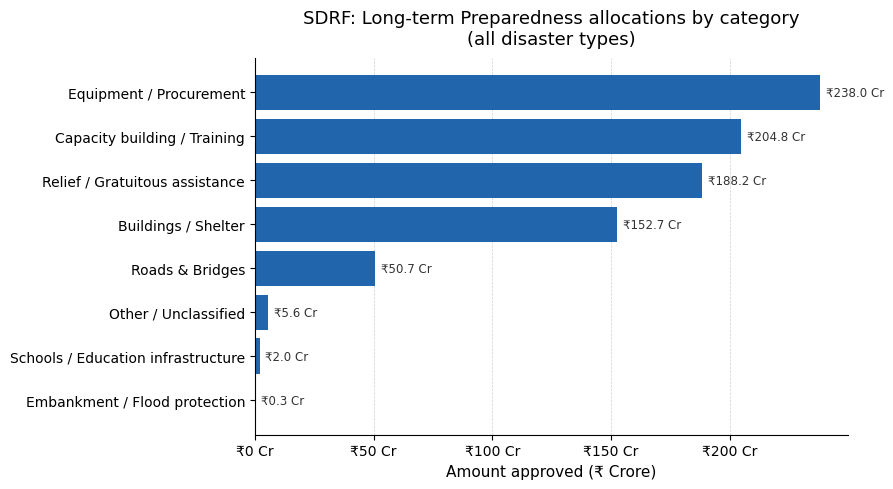

In [17]:
preparedness = sdrf.loc[sdrf['disaster_phase'] == 'Long-term Preparedness'].copy()

category_summary = (
    preparedness
    .groupby('work_type', as_index=False)['amount_inr_clean']
    .agg(total_amount_inr='sum', n_items='count')
)
category_summary['amount_cr'] = category_summary['total_amount_inr'] / 1e7
category_summary['share_pct'] = (
    category_summary['total_amount_inr'] / category_summary['total_amount_inr'].sum() * 100
)
category_summary = category_summary.sort_values('amount_cr', ascending=False).reset_index(drop=True)

print(category_summary[['work_type', 'n_items', 'amount_cr', 'share_pct']]
      .to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

# --- chart ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(category_summary['work_type'], category_summary['amount_cr'],
        color="#2166ac", zorder=2)
ax.invert_yaxis()  # largest category on top
ax.set_xlabel("Amount approved (₹ Crore)", fontsize=11)
ax.set_title("SDRF: Long-term Preparedness allocations by category\n(all disaster types)",
             fontsize=13, pad=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"₹{v:,.0f} Cr"))
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

for i, val in enumerate(category_summary['amount_cr']):
    ax.text(val + max(category_summary['amount_cr']) * 0.01, i,
            f"₹{val:,.1f} Cr", va="center", fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()


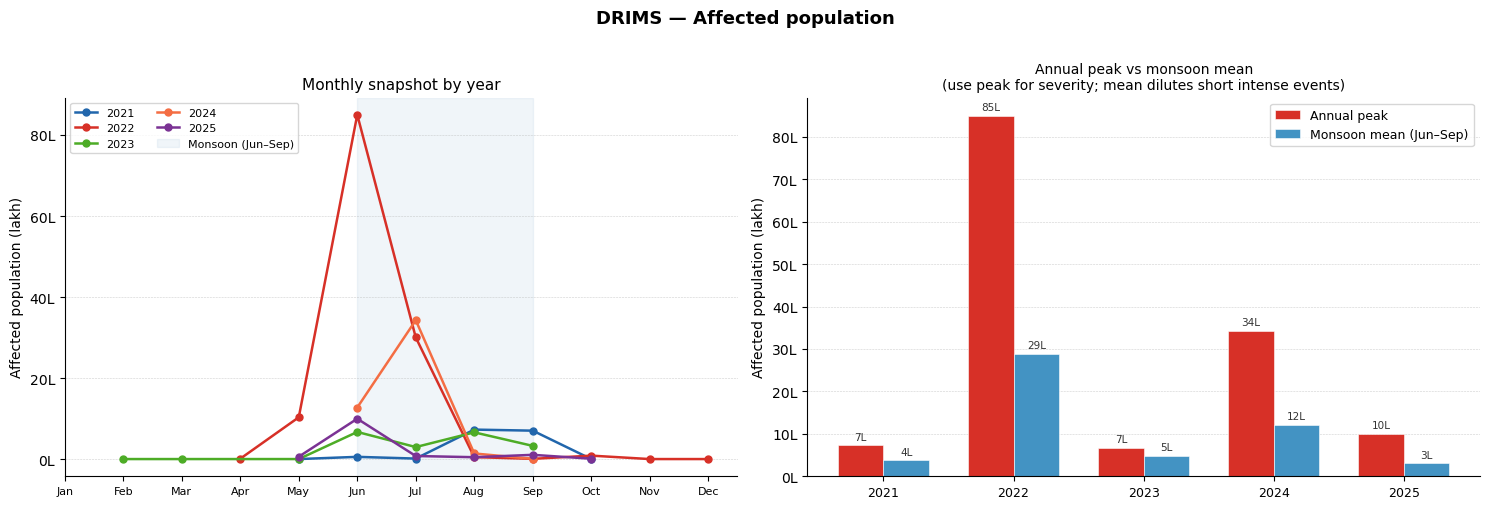

      Annual peak  Monsoon mean
year                           
2021       727348        373715
2022      8499660       2888961
2023       669295        487586
2024      3427982       1211090
2025       995590        305316


In [37]:
import json, glob, os

DRIMS_DIR = r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/DRIMS/data/DRIMS_api_output"

rows = []
for fpath in sorted(glob.glob(os.path.join(DRIMS_DIR, "*.json"))):
    year, month = map(int, os.path.basename(fpath).replace(".json", "").split("_"))
    with open(fpath) as f:
        d = json.load(f)
    total = sum(r.get("total", 0) for r in d.get("affectedPopulation", []))
    rows.append({"year": year, "month": month, "affected_pop": total})

drims = pd.DataFrame(rows)

annual_peak  = drims.groupby("year")["affected_pop"].max()
monsoon      = drims[drims["month"].between(6, 9)]
monsoon_mean = monsoon.groupby("year")["affected_pop"].mean()

PLOT_YEARS   = [2021, 2022, 2023, 2024, 2025]
YEAR_COLORS  = {2021: "#2166ac", 2022: "#d73027", 2023: "#4dac26", 2024: "#f46d43", 2025: "#7b3294"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("DRIMS — Affected population", fontsize=13, fontweight="bold", y=1.01)

# Panel 1 — monthly time series per year
ax = axes[0]
for yr in PLOT_YEARS:
    sub = drims[drims["year"] == yr].sort_values("month")
    ax.plot(sub["month"], sub["affected_pop"] / 1e5,
            marker="o", markersize=5, linewidth=1.8,
            color=YEAR_COLORS[yr], label=str(yr))
ax.axvspan(6, 9, alpha=0.08, color="steelblue", label="Monsoon (Jun–Sep)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=8)
ax.set_ylabel("Affected population (lakh)", fontsize=10)
ax.set_title("Monthly snapshot by year", fontsize=11, pad=6)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}L"))
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, ncol=2)

# Panel 2 — annual peak vs monsoon mean
ax2 = axes[1]
x  = np.arange(len(PLOT_YEARS))
w  = 0.35
b1 = ax2.bar(x - w/2, [annual_peak.get(y, 0) / 1e5  for y in PLOT_YEARS],
             w, label="Annual peak",           color="#d73027", edgecolor="white", linewidth=0.4, zorder=2)
b2 = ax2.bar(x + w/2, [monsoon_mean.get(y, 0) / 1e5 for y in PLOT_YEARS],
             w, label="Monsoon mean (Jun–Sep)", color="#4393c3", edgecolor="white", linewidth=0.4, zorder=2)

for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        if v > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, v + ax2.get_ylim()[1] * 0.01,
                     f"{v:.0f}L", ha="center", va="bottom", fontsize=7.5, color="#333")

ax2.set_xticks(x)
ax2.set_xticklabels(PLOT_YEARS, fontsize=9)
ax2.set_ylabel("Affected population (lakh)", fontsize=10)
ax2.set_title("Annual peak vs monsoon mean\n(use peak for severity; mean dilutes short intense events)",
              fontsize=10, pad=6)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}L"))
ax2.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.6, zorder=1)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "Annual peak":  annual_peak.reindex(PLOT_YEARS),
    "Monsoon mean": monsoon_mean.reindex(PLOT_YEARS).round(0).astype("Int64"),
}).to_string())

In [21]:
# % of Oct-2025 and Jan-2026 SEC meeting allocations spent on critical infra
# Reuses infra_work_type and ids_dist_rec_2025_26_canon from the FY2025-26 analysis above.
MEETING_DATES = [pd.Timestamp("2025-04-09"), pd.Timestamp("2025-10-09"), pd.Timestamp("2026-01-28")]

df_meetings = sdrf.copy()
df_meetings["meeting_date"] = pd.to_datetime(df_meetings["meeting_date"], errors="coerce")

def infra_share(df, label):
    sub = df.loc[df["amount_inr_clean"].notna()]
    by_work = sub.groupby("work_type")["amount_inr_clean"].sum().sort_values(ascending=False)
    total = by_work.sum()
    infra_total = by_work[by_work.index.isin(infra_work_type)].sum()
    pct = infra_total / total * 100 if total else float("nan")
    print(f"{label}: total ₹{total/1e7:,.1f} Cr | infra ₹{infra_total/1e7:,.1f} Cr | infra share {pct:.1f}%")
    return pct

recent = df_meetings.loc[df_meetings["meeting_date"].isin(MEETING_DATES)]

# same district filter used for the 29.5% FY2025-26 figure
recent_rec_dist = recent.loc[recent["district_canon"].isin(ids_dist_rec_2025_26_canon)]
pct_rec_dist = infra_share(recent_rec_dist, "Oct'25 + Jan'26 (rec districts only)")

# no district filter, for comparison
pct_all_dist = infra_share(recent, "Oct'25 + Jan'26 (all districts)")

print(f"\nFY2025-26 full-year figure (rec districts): {infra_pct:.1f}%")
print(f"Oct'25+Jan'26 alone (rec districts):        {pct_rec_dist:.1f}%  -> {'still ~29.5%' if abs(pct_rec_dist-29.5)<1 else 'diverges'}")
print(f"Oct'25+Jan'26 alone (all districts):         {pct_all_dist:.1f}%  -> driven down by non-infra spend in districts outside the rec list")


Oct'25 + Jan'26 (rec districts only): total ₹398.4 Cr | infra ₹117.3 Cr | infra share 29.4%
Oct'25 + Jan'26 (all districts): total ₹3,818.0 Cr | infra ₹210.1 Cr | infra share 5.5%

FY2025-26 full-year figure (rec districts): 29.4%
Oct'25+Jan'26 alone (rec districts):        29.4%  -> still ~29.5%
Oct'25+Jan'26 alone (all districts):         5.5%  -> driven down by non-infra spend in districts outside the rec list


### INR Amount column cleanup 

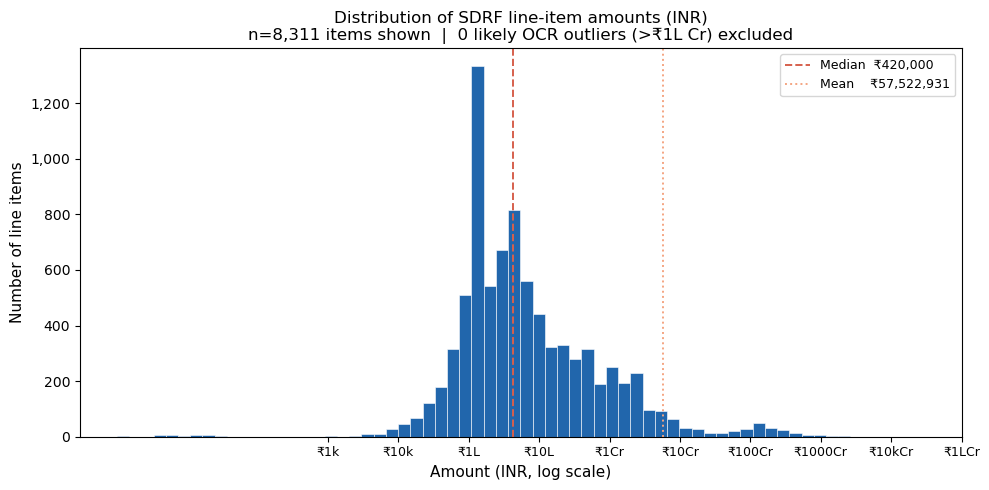

Statistic                           Value
------------------------------------------
Count (valid)                       8,311
Nulls                                  31
OCR outliers                            0
Min                                    ₹1
Median                           ₹420,000
Mean                          ₹57,522,931
95th pct                      ₹45,170,641
Max (clean)               ₹26,429,900,000


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

line_items = pd.read_csv(
    r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items.csv"
)

amounts = line_items["amount_inr"].dropna()
amounts = amounts[amounts > 0]

# Amounts span ~12 orders of magnitude; log10 scale gives a readable distribution.
# Values above 1e12 (>10,000 crore) are almost certainly OCR parse errors.
OUTLIER_THRESHOLD = 1e12
clean   = amounts[amounts <= OUTLIER_THRESHOLD]
outlier = amounts[amounts >  OUTLIER_THRESHOLD]

log_vals = np.log10(clean)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(log_vals, bins=60, color="#2166ac", edgecolor="white", linewidth=0.4)

# Label x-axis with rupee values instead of log exponents
rupee_ticks = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
rupee_labels = ["₹1k", "₹10k", "₹1L", "₹10L", "₹1Cr", "₹10Cr",
                "₹100Cr", "₹1000Cr", "₹10kCr", "₹1LCr"]
ax.set_xticks(rupee_ticks)
ax.set_xticklabels(rupee_labels, fontsize=9)

ax.axvline(np.log10(clean.median()), color="#d6604d", linestyle="--",
           linewidth=1.4, label=f"Median  ₹{clean.median():,.0f}")
ax.axvline(np.log10(clean.mean()),   color="#f4a582", linestyle=":",
           linewidth=1.4, label=f"Mean    ₹{clean.mean():,.0f}")

ax.set_xlabel("Amount (INR, log scale)", fontsize=11)
ax.set_ylabel("Number of line items", fontsize=11)
ax.set_title(
    f"Distribution of SDRF line-item amounts (INR)\n"
    f"n={len(clean):,} items shown  |  {len(outlier)} likely OCR outliers (>₹1L Cr) excluded",
    fontsize=12
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"{'Statistic':<20} {'Value':>20}")
print("-" * 42)
for label, val in [
    ("Count (valid)",    f"{len(clean):,}"),
    ("Nulls",            f"{line_items['amount_inr'].isna().sum():,}"),
    ("OCR outliers",     f"{len(outlier):,}"),
    ("Min",              f"₹{clean.min():,.0f}"),
    ("Median",           f"₹{clean.median():,.0f}"),
    ("Mean",             f"₹{clean.mean():,.0f}"),
    ("95th pct",         f"₹{clean.quantile(0.95):,.0f}"),
    ("Max (clean)",      f"₹{clean.max():,.0f}"),
]:
    print(f"{label:<20} {val:>20}")

Summary: amount_inr Parsing Issues in Cache
154 unique affected items across 21 meetings. Three distinct root causes:

Category A — Double Unit Suffix (16 items, values inflated ×100)
The raw string explicitly contains "Cr." or "lakh" and the page default_amount_unit was also applied on top, squaring the multiplier.

Meeting	Raw	Default Unit	Stored (wrong)	Correct
42nd / 0003	"178.79 Cr."	crore	₹178,790,000,000	₹1,787,900,000
51st / 0004	"Rs. 140.20 Cr."	crore	₹140,200,000,000	₹1,402,000,000
51st / 0004	"Rs. 411.12 Cr."	crore	₹411,120,000,000	₹4,111,200,000
54th / 0006	"Rs. 313.69 Cr."	crore	₹313,690,000,000	₹3,136,900,000
39th / 0016	"Rs. 6.00 Cr."	lakh	₹6,000,000,000	₹60,000,000
40th / 0002	"Rs. 5.00 Cr."	lakh	₹5,000,000,000	₹50,000,000
Fix: When raw contains an explicit unit suffix, use only that suffix and ignore default_amount_unit.

Category B — Indian-Format Rupees Multiplied by Unit (138 items, values inflated ×10⁵ to ×10⁷)
Raw values use Indian comma notation (e.g., 17,00,000 = ₹17 lakh, 8,49,25,790 = ₹8.49 crore). The parser stripped commas and treated the result as a "lakh" or "crore" count, then multiplied — producing astronomically wrong values.

Sub-case B1: inflated (stored ×100,000 or ×10,000,000 too large)

Meeting	Raw	Unit	Stored	Correct
41st / 0001	"17,00,000"	lakh	₹170,000,000,000	₹1,700,000
41st / 0097	"49,27,13,595"	lakh	₹49,271,359,500,000	₹492,713,595
49th / 0002	"8,49,25,790"	crore	₹849,257,900,000,000	₹84,925,790
44th / 0002	"1,33,36,502"	crore	₹133,365,020,000,000	₹13,336,502
51st / 0006	"1,11,98,100/-"	crore	₹111,981,000,000,000	₹11,198,100
10th / 0023	"50,00,000"	lakh	₹500,000,000,000	₹5,000,000
...and ~130 more				
Sub-case B2: stored too small (~35 items with /- suffix)

These Indian-format amounts with /- were read as a fraction of a lakh. The parser appears to have interpreted the first two comma-groups as X.Y rather than as Indian digits:

Meeting	Raw	Stored (wrong)	Correct
42nd / 0048	"Rs.7,15,000/-"	₹71,500	₹715,000
42nd / 0048	"Rs.10,50,000/-"	₹10,500	₹1,050,000
42nd / 0048	"Rs.15,79,500/-"	₹15,795	₹1,579,500
41st / 0003	"Rs. 4,24,65,000"	₹42,465	₹42,465,000
55th / 0003	"Rs.1,31,87,680/-"	₹13,188	₹13,187,680
39th / 0016	"Rs. 12,45,000/-"	₹12,450	₹1,245,000
Category C — Source Data Issue (39th meeting, page 0002)
Raw values like "470695.48", "11064726.00", "2719200.00" with default_unit=lakh. If the PDF table header says "Rs. in Lakh", then these ARE lakh values (correct). But the resulting amounts (e.g., 470,695 lakh = ₹4,707 crore for a single crop category) seem implausibly large for 2019 Assam SDRF agricultural assistance. This needs source PDF verification — either the raw values are correctly in lakh (the stored amount_inr is right), or the table header was "Rs." not "Rs. in Lakh" and the values are already rupees.

Also notable: 47th meeting unit=rupees
"Rs. 61,02,060/-" with unit=rupees is stored as amount_inr=₹0.61 — the Indian-format parsing with /-  suffix applied in a rupees-unit context divided down to near-zero. Correct value: ₹6,102,060.

Scale in line_items.csv:

239 rows with amount_inr > ₹1,000 crore (almost all wrong)
76 rows with amount_inr > ₹10,000 crore (certainly wrong)
55 rows with amount_inr < ₹1,000 (likely too small)
The fix needs to be applied in the extraction script (02_extract_data.py) — the amount_inr and amount_lakh computation must: (1) detect Indian-comma format and treat it as rupees directly, (2) not apply default_amount_unit when the raw string already has a unit suffix.

## `amount_inr` Parsing Audit

Scans every cache JSON to detect three classes of incorrect `amount_inr` values produced by the extraction pipeline:

| Category | Root cause | Typical error |
|---|---|---|
| **A** | Raw string has a unit suffix *and* `default_amount_unit` also applied | ×100 too large |
| **B (large)** | Indian-comma rupee format (e.g. `17,00,000`) multiplied by page unit | ×10⁵ – ×10⁷ too large |
| **B (small)** | Indian-comma amount with `/-` suffix parsed as fractional lakh | 10–100× too small |

Run all cells below to regenerate the full issue list.

In [39]:
import json, os, re
from pathlib import Path
from collections import defaultdict

CACHE_DIR = Path("/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/cache")

CRORE = 10_000_000
LAKH  = 100_000

def _strip_currency(s: str) -> str:
    return re.sub(r"(?i)rs\.?|/-|\s", "", s).strip()

def _unit_suffix(s: str):
    """Return 'crore' or 'lakh' if the raw string contains an explicit unit, else None."""
    m = re.search(r"(?i)\b(crore|cr\.?|lakh|lac)\b", s)
    if not m:
        return None
    tok = m.group(1).lower().rstrip(".")
    return "crore" if tok in ("crore", "cr") else "lakh"

def _is_indian_comma(s: str):
    """
    Return (True, rupee_value) if the string is Indian-notation rupees
    (groups of 2 digits after the leading group, final group of 3).
    e.g. 17,00,000 / 8,49,25,790 / 49,27,13,595
    """
    clean = _strip_currency(s)
    clean = re.sub(r"(?i)(crore|cr\.?|lakh|lac)$", "", clean).strip()
    if re.fullmatch(r"\d{1,2}(,\d{2})*,\d{3}", clean):
        return True, float(clean.replace(",", ""))
    return False, None

def scan_cache(cache_dir: Path) -> list[dict]:
    """
    Walk every meeting/page JSON in cache_dir.
    Return a deduplicated list of issue dicts, one per (meeting, page, raw) triple.
    """
    seen = set()
    issues = []

    for meeting in sorted(cache_dir.iterdir()):
        if not meeting.is_dir():
            continue
        for page_file in sorted(meeting.iterdir()):
            if page_file.suffix != ".json":
                continue
            data = json.loads(page_file.read_text())
            page_unit = data.get("default_amount_unit")  # lakh / crore / rupees / None

            for item in data.get("line_items", []):
                raw = str(item.get("amount_raw", ""))
                amt = item.get("amount_inr")
                if amt is None:
                    continue

                key = (meeting.name, page_file.name, raw)
                if key in seen:
                    continue
                seen.add(key)

                work = (item.get("work_text") or "")[:80]
                suffix = _unit_suffix(raw)

                # ── Category A: embedded unit suffix AND page unit both applied ──
                if suffix and page_unit in ("lakh", "crore"):
                    clean = re.sub(r"(?i)rs\.?|/-|crore|cr\.?|lakh|lac|\s", "", raw).strip()
                    try:
                        val = float(clean.replace(",", ""))
                    except ValueError:
                        continue
                    mult = CRORE if suffix == "crore" else LAKH
                    correct = val * mult
                    if correct > 0 and abs(correct - amt) / max(abs(amt), 1) > 0.01:
                        issues.append(dict(
                            category="A – double unit suffix",
                            meeting=meeting.name, page=page_file.name,
                            default_unit=page_unit, raw=raw,
                            stored_inr=amt, correct_inr=correct,
                            error_factor=amt / correct,
                            work=work,
                        ))
                    continue

                # ── Category B: Indian-comma rupee value multiplied by page unit ──
                is_indian, rupee_val = _is_indian_comma(raw)
                if is_indian and page_unit in ("lakh", "crore") and rupee_val:
                    mult = LAKH if page_unit == "lakh" else CRORE
                    category = (
                        "B-large (Indian format × unit)"
                        if amt > rupee_val
                        else "B-small (Indian format ÷ unit)"
                    )
                    issues.append(dict(
                        category=category,
                        meeting=meeting.name, page=page_file.name,
                        default_unit=page_unit, raw=raw,
                        stored_inr=amt, correct_inr=rupee_val,
                        error_factor=amt / rupee_val,
                        work=work,
                    ))

    return issues


issues = scan_cache(CACHE_DIR)
print(f"Total unique issues: {len(issues)}")
for cat, grp in sorted(defaultdict(list, 
    {k: [i for i in issues if i['category'] == k] for k in {i['category'] for i in issues}}
).items()):
    print(f"  {cat}: {len(grp)}")

Total unique issues: 138
  B-small (Indian format ÷ unit): 138


In [40]:
import pandas as pd

df = pd.DataFrame(issues)

def _fmt_inr(v):
    if v >= 1e7:
        return f"₹{v/1e7:.2f} Cr"
    if v >= 1e5:
        return f"₹{v/1e5:.2f} L"
    return f"₹{v:,.0f}"

df["stored"] = df["stored_inr"].apply(_fmt_inr)
df["correct"] = df["correct_inr"].apply(_fmt_inr)
df["error_×"] = df["error_factor"].apply(lambda x: f"×{x:,.0f}" if x >= 1 else f"÷{1/x:,.0f}")

display_cols = ["category", "meeting", "page", "default_unit", "raw", "stored", "correct", "error_×", "work"]

for cat in sorted(df["category"].unique()):
    sub = df[df["category"] == cat][display_cols].reset_index(drop=True)
    print(f"\n{'─'*80}")
    print(f"  {cat}  ({len(sub)} items)")
    print(f"{'─'*80}")
    display(sub.style.set_properties(**{"text-align": "left", "font-size": "12px"})
              .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


────────────────────────────────────────────────────────────────────────────────
  B-small (Indian format ÷ unit)  (138 items)
────────────────────────────────────────────────────────────────────────────────


,category,meeting,page,default_unit,raw,stored,correct,error_×,work
0,B-small (Indian format ÷ unit),10th_SEC_Meeting,0009.json,lakh,"38,56,508/-",₹38.57 L,₹38.57 L,×1,"Procurement of two wooden boats each for Majuli, Sadiya and Salmara Sub-Division"
1,B-small (Indian format ÷ unit),10th_SEC_Meeting,0018.json,lakh,"27,645","₹27,645","₹27,645",×1,"Non submission of Service Tax challan amounting to Rs 27,645/ by the Travel Agen"
2,B-small (Indian format ÷ unit),10th_SEC_Meeting,0023.json,lakh,"50,00,000",₹50.00 L,₹50.00 L,×1,Sensitization meetings/ IEC materials/Audio Visual/ Advertisement etc.
3,B-small (Indian format ÷ unit),10th_SEC_Meeting,0023.json,lakh,"40,50,000",₹40.50 L,₹40.50 L,×1,Updation of District Disaster Management Plan
4,B-small (Indian format ÷ unit),10th_SEC_Meeting,0023.json,lakh,"10,00,000",₹10.00 L,₹10.00 L,×1,State level Workshop / Conference on: i) State Disaster Resource Network (SDRN)
5,B-small (Indian format ÷ unit),10th_SEC_Meeting,0023.json,lakh,"5,00,00,000",₹5.00 Cr,₹5.00 Cr,×1,Total
6,B-small (Indian format ÷ unit),39th_sec_meeting,0003.json,lakh,"10,00,000",₹10.00 L,₹10.00 L,×1,Professional Fees
7,B-small (Indian format ÷ unit),39th_sec_meeting,0003.json,lakh,"31,00,000",₹31.00 L,₹31.00 L,×1,Office Expenditure
8,B-small (Indian format ÷ unit),39th_sec_meeting,0003.json,lakh,"1,55,00,000",₹1.55 Cr,₹1.55 Cr,×1,Response Fund
9,B-small (Indian format ÷ unit),39th_sec_meeting,0003.json,lakh,"35,00,000",₹35.00 L,₹35.00 L,×1,Equipment


In [41]:
LINE_ITEMS_CSV = Path("/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items.csv")

li = pd.read_csv(LINE_ITEMS_CSV)

thresholds = [
    (">₹10,000 Cr  (certainly wrong)",  1e12),
    (">₹1,000 Cr   (almost certainly wrong)", 1e11),
    (">₹100 Cr     (plausible but flag)", 1e10),
    ("<₹1,000      (likely too small)",  None),
]

print("line_items.csv  —  amount_inr outlier summary")
print(f"  Total rows:  {len(li):,}")
print(f"  Null/zero:   {(li['amount_inr'].isna() | (li['amount_inr'] == 0)).sum():,}")
print()

valid = li["amount_inr"].dropna()
for label, threshold in thresholds:
    if threshold:
        mask = valid > threshold
    else:
        mask = valid < 1_000
    count = mask.sum()
    print(f"  {label}: {count:>5,} rows")

print()
print("Top 10 largest amount_inr rows:")
top10 = li.nlargest(10, "amount_inr")[["meeting_number", "source", "page", "amount_inr", "work_text"]]
top10["amount_inr"] = top10["amount_inr"].apply(_fmt_inr)
display(top10.reset_index(drop=True))

print("\nRows with amount_inr < ₹1,000 (sample):")
tiny = li[li["amount_inr"] < 1_000][["meeting_number", "source", "page", "amount_inr", "work_text"]].head(15)
display(tiny.reset_index(drop=True))

line_items.csv  —  amount_inr outlier summary
  Total rows:  8,344
  Null/zero:   33

  >₹10,000 Cr  (certainly wrong):     0 rows
  >₹1,000 Cr   (almost certainly wrong):     0 rows
  >₹100 Cr     (plausible but flag):     3 rows
  <₹1,000      (likely too small):    30 rows

Top 10 largest amount_inr rows:


,meeting_number,source,page,amount_inr,work_text
0,42.0,42nd_sec_meeting,2,₹2642.99 Cr,TOTAL
1,54.0,54th_sec_meeting,5,₹1270.79 Cr,Approval of fund under National Disaster Respo...
2,42.0,42nd_sec_meeting,2,₹1194.97 Cr,Water Resource Department
3,42.0,42nd_sec_meeting,52,₹991.20 Cr,Immediate restoration of storm damage 11 KV & ...
4,44.0,44th_sec_meeting,42,₹965.00 Cr,Temporary Restoration of flood damaged to HP C...
5,44.0,44th_sec_meeting,46,₹920.00 Cr,"Restoration by providing Bamboo foot bridge, b..."
6,44.0,44th_sec_meeting,43,₹880.00 Cr,Construction of bamboo foot bridge (temp. rest...
7,42.0,42nd_sec_meeting,52,₹873.20 Cr,Immediate restoration of storm damage 11 KV & ...
8,44.0,44th_sec_meeting,43,₹860.00 Cr,Construction of bamboo foot bridge for restora...
9,44.0,44th_sec_meeting,42,₹856.30 Cr,Temporary restoration of flood damaged to Kalg...



Rows with amount_inr < ₹1,000 (sample):


,meeting_number,source,page,amount_inr,work_text
0,41.0,41st_sec_meeting,3,33.00,Approval for payment of bills for Disaster Man...
1,44.0,44th_sec_meeting,9,0.00,Development of ASDMA Land & Construction of AS...
2,45.0,45th_sec_meeting,4,1.00,Rugged Tablets for all District Project Office...
3,51.0,51th_sec_meeting_0,57,0.00,66500
4,52.0,52nd_sec_meeting,8,4.73,Protection of Different reaches at Koyakuchi a...
5,52.0,52nd_sec_meeting,8,18.79,Anti Erosion measures to protect Kalakati Sing...
6,52.0,52nd_sec_meeting,8,29.00,Protection of Gobindapur-Tinkonia area from th...
7,52.0,52nd_sec_meeting,8,10.96,Anti Erosion measures to Protect Ramsing Gram ...
8,52.0,52nd_sec_meeting,8,6.19,Anti erosion measures to Protect Deb Para area...
9,52.0,52nd_sec_meeting,8,5.00,Anti erosion measures to Protect Singirbond ar...
